Below we present the training and validation results of a Graph Attention Network (GAT) model. A GAT is a graph neural network that leverages attention mechanisms to assign higher weights to more informative or suspicious neighboring nodes, enabling the model to focus on critical local structures in the graph.

In [1]:
# Preparation and data loading.

from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/2026 Deep Learning Bitcoin Fraud Detection

!pip install torch_geometric

import torch
from torch_geometric.data import Data

elliptic = torch.load("./Dataset/processed/transaction_graph_v1.pt", weights_only=False, map_location="cpu")
txs_data = Data(**elliptic[0])

indices_to_remove = {}
all_indices = [i for i in range(txs_data.x.shape[1]) if i not in indices_to_remove]
txs_data.x = txs_data.x[:, all_indices]

txs_data

Mounted at /content/drive
/content/drive/MyDrive/2026 Deep Learning Bitcoin Fraud Detection
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 79.3 MB/s eta 0:00:00


Data(x=[203769, 166], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])

In [2]:
# Implement strict time-forward train/val/test split
time_steps = txs_data.x[:,0]
train_mask = (time_steps >= 1) & (time_steps <= 32)
val_mask = (time_steps >= 33) & (time_steps <= 37)
test_mask = (time_steps >= 38) & (time_steps <= 42)

# Select the labeled data and make the train/val/test sets
labeled = txs_data.y != 2
train_idx = train_mask & labeled
val_idx = val_mask & labeled
test_idx = test_mask & labeled

print("The size of the training set is:", train_idx.sum().item())
print("The size of the validation set is:",val_idx.sum().item())
print("The size of the testing set is:", test_idx.sum().item())

The size of the training set is: 28938
The size of the validation set is: 4503
The size of the testing set is: 6436


In [3]:
# Architecture preparation.

import torch
import torch.nn.functional as F
from torch_geometric.nn import GATConv

# Definine the GAT class (GAT for Graph ATtention network), which is a neural network which puts heavier weights towards suspicious graphical neighborhoods.
# We set the heads number, which allows the network to run multiple independent attention computations in parallel, for the hidden layers as 8,
# and that for the output layer as 1. We also set 'v2' to be True, which sets the GAT attention to be dynamic.

class GAT(torch.nn.Module):

    def __init__(self, in_channels: int, hidden: int, out_channels: int, heads: int = 8, dropout: float = 0.2, edge_dim = 16, v2 = True):
        super().__init__()

        self.dropout = dropout

        # first attention layer
        self.conv1 = GATConv(
            in_channels,
            hidden,
            heads=heads,
            dropout=dropout
        )

        # second attention layer
        self.conv2 = GATConv(
            hidden * heads,
            out_channels,
            heads=1,
            concat=False,
            dropout=dropout
        )

    def forward(self, x, edge_index):

        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv1(x, edge_index)
        x = F.relu(x)            # Using ReLu as the activation function.

        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)

        return x


In [4]:
# Network training.

import copy
from torch_geometric.utils import to_undirected
from sklearn.metrics import average_precision_score
from IPython.display import clear_output

# Load the dataset
x = txs_data.x[:,1:] # drop the time step feature
y = txs_data.y
edge_index = txs_data.edge_index
edge_index_undir = to_undirected(edge_index) #conversion to undirected graph

# Store the dataset on GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x_gpu = x.to(device)
y_gpu = y.to(device)
edge_index_gpu = edge_index.to(device)
edge_index_undir_gpu = edge_index_undir.to(device)

train_idx_gpu = train_idx.to(device)
val_idx_gpu = val_idx.to(device)
test_idx_gpu = test_idx.to(device)

# Compute class weights from train labels
y_train = y_gpu[train_idx_gpu]
nums_0 = (y_train == 0).sum().item()
nums_1 = (y_train == 1).sum().item()

w0 = 1.0
w1 = nums_0/max(nums_1, 1)
class_weight = torch.tensor([w0, w1], device = device)

# Train a GAT model with 10 hidden units.
model = GAT(in_channels = x.size(1), hidden = 10, out_channels = 2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3, weight_decay= 1e-3)

best_val_ap, best_state = -1, None
patience = 100
min_delta = 1e-4
bad_epochs = 0
epochs = 1000

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    # Do forward pass and compute loss
    logits = model(x_gpu, edge_index_undir_gpu)
    loss = F.cross_entropy(logits[train_idx_gpu], y_gpu[train_idx_gpu], weight = class_weight)

    # Do backward pass and update weights
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
      logits = model(x_gpu, edge_index_undir_gpu)
      val_prob = F.softmax(logits[val_idx_gpu], dim = 1)[:,1]
      val_ap = average_precision_score(y[val_idx], val_prob.cpu().numpy())

    # Evaluate the model's performance on the validation set
    # Stop early if the performance does not improve
    if val_ap > best_val_ap + min_delta:
      best_val_ap = val_ap
      best_state = copy.deepcopy(model.state_dict())
      bad_epochs = 0
    else:
      bad_epochs += 1

    if bad_epochs >= patience:
      break

    clear_output(wait=True)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

model.load_state_dict(best_state)
print("Best average precision on the validation set is", best_val_ap)

Epoch 466/1000, Loss: 0.1677
Best average precision on the validation set is 0.7862364103491135


Train: PR-AUC(trapz)=0.9551 | AP=0.9551
Val:   PR-AUC(trapz)=0.7859   | AP=0.7862
Test:  PR-AUC(trapz)=0.6947  | AP=0.6949


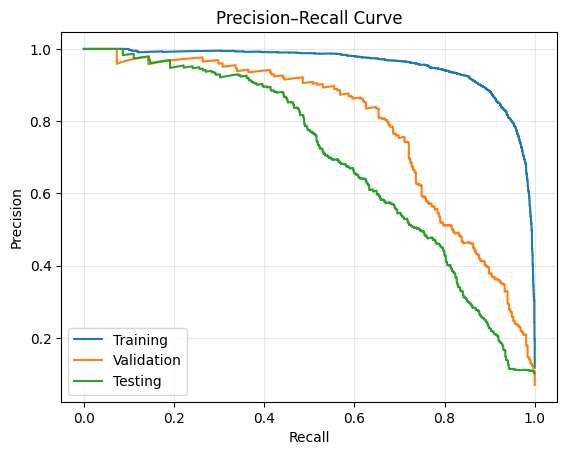

Train: ROC-AUC=0.9926
Val:   ROC-AUC=0.9630
Test:  ROC-AUC=0.8890


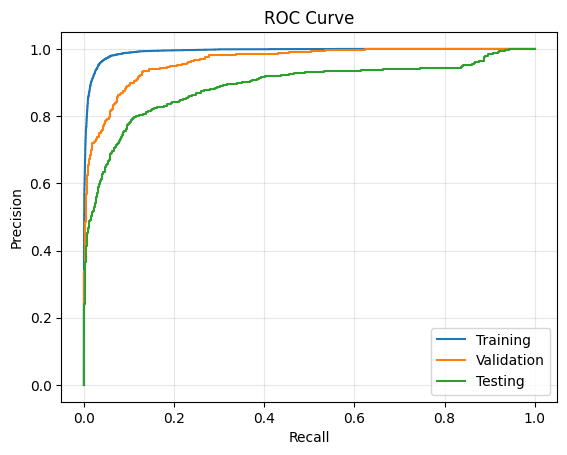

In [7]:
# Visulization of the classification performance.

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    auc,
    average_precision_score,
    roc_auc_score,
)

model.eval()
with torch.no_grad():
    out = model(x_gpu, edge_index_undir_gpu)

    # Support both (logits) and (logits, embeddings) return signatures
    if isinstance(out, tuple):
        logits, h1 = out
        h1 = h1.detach().cpu()
    else:
        logits = out
        h1 = None

    y_scores = F.softmax(logits, dim=1)[:, 1]  # P(class=1)


y_np = y.detach().cpu().numpy()
y_scores_np = y_scores.detach().cpu().numpy()

train_idx_np = train_idx.detach().cpu().numpy()
val_idx_np   = val_idx.detach().cpu().numpy()
test_idx_np  = test_idx.detach().cpu().numpy()

def pr_stats(split_name, idx):
    y_true = y_np[idx]
    y_pred = y_scores_np[idx]

    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    pr_auc = auc(recall, precision)
    ap = average_precision_score(y_true, y_pred)

    return precision, recall, pr_auc, ap

# Extract PR stats.
train_p, train_r, train_pr_auc, train_ap = pr_stats("train", train_idx_np)
val_p,   val_r,   val_pr_auc,   val_ap   = pr_stats("val",   val_idx_np)
test_p,  test_r,  test_pr_auc,  test_ap  = pr_stats("test",  test_idx_np)

print(f"Train: PR-AUC(trapz)={train_pr_auc:.4f} | AP={train_ap:.4f}")
print(f"Val:   PR-AUC(trapz)={val_pr_auc:.4f}   | AP={val_ap:.4f}")
print(f"Test:  PR-AUC(trapz)={test_pr_auc:.4f}  | AP={test_ap:.4f}")

# plot PR curves
plt.figure()
plt.plot(train_r, train_p, label="Training")
plt.plot(val_r, val_p, label="Validation")
plt.plot(test_r, test_p, label="Testing")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Extract ROC stats.
train_fpr, train_tpr, _ = roc_curve(y_np[train_idx_np], y_scores_np[train_idx_np])
val_fpr, val_tpr, _ = roc_curve(y_np[val_idx_np], y_scores_np[val_idx_np])
test_fpr, test_tpr, _ = roc_curve(y_np[test_idx_np], y_scores_np[test_idx_np])
train_roc_auc = auc(train_fpr, train_tpr)
val_roc_auc = auc(val_fpr, val_tpr)
test_roc_auc = auc(test_fpr, test_tpr)

print(f"Train: ROC-AUC={train_roc_auc:.4f}")
print(f"Val:   ROC-AUC={val_roc_auc:.4f}")
print(f"Test:  ROC-AUC={test_roc_auc:.4f}")


# Plotting ROC curves.
plt.figure()
plt.plot(train_fpr, train_tpr, label="Training")
plt.plot(val_fpr, val_tpr, label="Validation")
plt.plot(test_fpr, test_tpr, label="Testing")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("ROC Curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Save PR-AUC summary
pr_auc_df = pd.DataFrame({
    "split":  ["train", "val", "test"],
    "PR_AUC": [train_pr_auc, val_pr_auc, test_pr_auc],
    "AP":     [train_ap, val_ap, test_ap],
})
pr_auc_df.to_csv("pr_auc.csv", index=False)

# Save ROC-AUC summary
roc_auc_df = pd.DataFrame({
    "split":   ["train", "val", "test"],
    "ROC_AUC": [train_roc_auc, val_roc_auc, test_roc_auc],
})
roc_auc_df.to_csv("roc_auc.csv", index=False)